In [2]:
import torch
import pickle as pkl

In [3]:
lidar_weight = 504126
gps_weight = 336530
img_weight = 839312

img_weight + lidar_weight + gps_weight

1679968

In [10]:
task_0 = pkl.load(open("./centralized/LIG_S1/flash/task0/mask.pkl", "rb"))
task_1 = pkl.load(open("./centralized/LIG_S1/flash/task1/mask.pkl", "rb"))
task_2_model = torch.load("./centralized/LIG_S1/flash/task2/cumu_model.pt", weights_only=True)

In [20]:
for name, param in task_2_model.items():
    if name == "out.weight":
        print(param[task_1["out.weight"].int()])

tensor([[[-0.0508, -0.0970, -0.0640,  ..., -0.0141, -0.0955, -0.1130],
         [ 0.0119,  0.0256, -0.1810,  ..., -0.1008, -0.1697,  0.1408],
         [-0.0508, -0.0970, -0.0640,  ..., -0.0141, -0.0955, -0.1130],
         ...,
         [-0.0508, -0.0970, -0.0640,  ..., -0.0141, -0.0955, -0.1130],
         [ 0.0119,  0.0256, -0.1810,  ..., -0.1008, -0.1697,  0.1408],
         [ 0.0119,  0.0256, -0.1810,  ..., -0.1008, -0.1697,  0.1408]],

        [[-0.0508, -0.0970, -0.0640,  ..., -0.0141, -0.0955, -0.1130],
         [-0.0508, -0.0970, -0.0640,  ..., -0.0141, -0.0955, -0.1130],
         [-0.0508, -0.0970, -0.0640,  ..., -0.0141, -0.0955, -0.1130],
         ...,
         [-0.0508, -0.0970, -0.0640,  ..., -0.0141, -0.0955, -0.1130],
         [ 0.0119,  0.0256, -0.1810,  ..., -0.1008, -0.1697,  0.1408],
         [ 0.0119,  0.0256, -0.1810,  ..., -0.1008, -0.1697,  0.1408]],

        [[-0.0508, -0.0970, -0.0640,  ..., -0.0141, -0.0955, -0.1130],
         [ 0.0119,  0.0256, -0.1810,  ..., -0

In [6]:
sum([v.numel() for v in task_0["out.weight"]])

16384

In [7]:
sum([v.sum() for v in task_0["out.weight"]])

tensor(4915.)

In [8]:
sum([v.numel() for v in task_1["out.weight"]])

16384

In [9]:
sum([v.sum() for v in task_1["out.weight"]])

tensor(8192.)

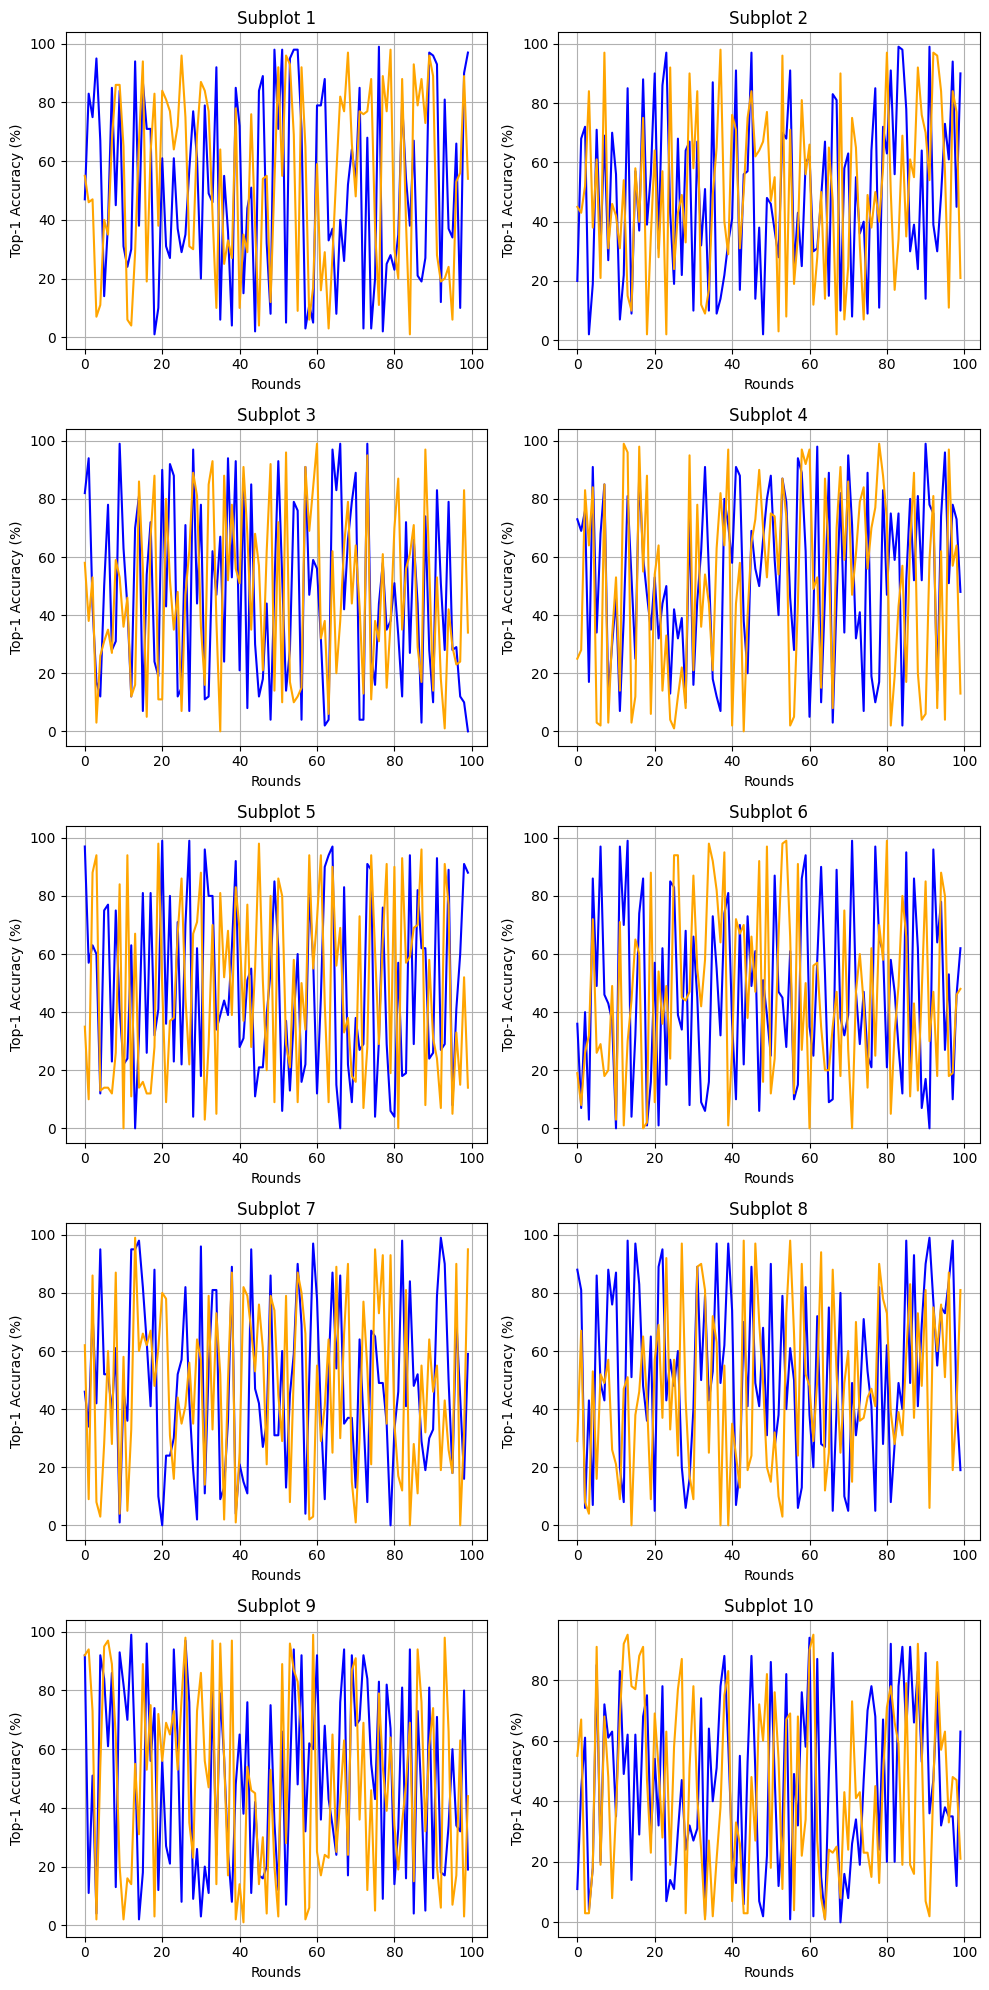

In [19]:
# Drawing figure
import numpy as np
import matplotlib.pyplot as plt

def generate_dummy(size=100):
    x = list(range(size))
    y = np.random.randint(0, 100, size)
    return x, y


# create sub-plots 5 row 2 column
fig, axs = plt.subplots(5, 2, figsize=(10, 20))

for i in range(5):
    for j in range(2):
        x, y = generate_dummy()
        axs[i, j].plot(x, y, color="blue")
        x, y = generate_dummy()
        axs[i, j].plot(x, y, color="orange")
        axs[i, j].set_title(f"Subplot {i*2 + j + 1}")
        axs[i, j].set_xlabel("Rounds")
        axs[i, j].set_ylabel("Top-1 Accuracy (%)")
        axs[i, j].grid(True)

plt.tight_layout()
plt.show()
